<a href="https://colab.research.google.com/github/cpt0/data201-labs/blob/main/Copy_of_Week_6_Tuning_a_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# imports
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     KFold, StratifiedKFold, LeaveOneOut, GridSearchCV)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
#from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_iris
from sklearn.metrics import mean_squared_error, roc_auc_score

### Part 1: Auto

We will use polynomial regression to predict mpg from horsepower

(392, 9)


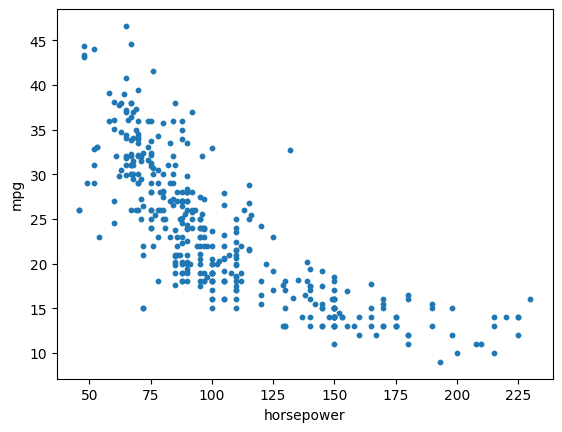

In [ ]:
auto = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Auto.csv")

# Convert horsepower to numeric
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')

# Remove rows with missing horsepower
auto = auto.dropna(subset=['horsepower'])

print(auto.shape)

X = auto[['horsepower']].values
y = auto['mpg'].values

plt.scatter(X, y, s=10)
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

**Objective 1:** See how model flexibility affects training and validation error using one train/validation split.

**What to expect:** As polynomial degree increases, training error should decrease. Validation error may decrease at first, then increase if the model begins to overfit.

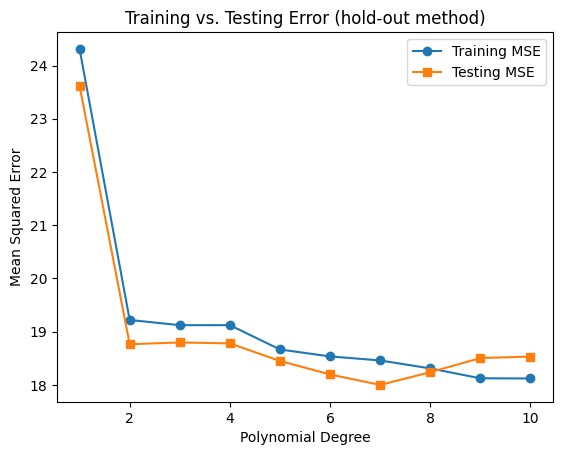

In [ ]:
#Underfitting vs. overfitting using one 50/50 validation split

# Polynomial degrees to compare
degrees = range(1, 11)

#Using the pipeline to create the function that builds a polynomial regression model
def poly_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False), #bias=F avoids adding an extra intercept column
        StandardScaler(),
        LinearRegression()   #the model becomes quadratic in degree=2)
    )

#Split the data once: 50% training and 50% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=0
)

train_mse = []
test_mse = []

#Fit a model for each polynomial degree
for degree in degrees:

    model = poly_model(degree)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate MSE
    train_mse.append(
        mean_squared_error(y_train, y_train_pred)
    )

    test_mse.append(
        mean_squared_error(y_test, y_test_pred)
    )

# Plot training and validation error
plt.plot(degrees, train_mse, 'o-', label='Training MSE')
plt.plot(degrees, test_mse, 's-', label='Testing MSE')

plt.xlabel('Polynomial Degree'); plt.ylabel('Mean Squared Error'); plt.title('Training vs. Testing Error (hold-out method)'); plt.legend()
plt.show()

For every degree, we train the model using the same training set and then measure:
- Training MSE: error on data the model learned from
- Testing MSE: error on data the model did not learn from

As degree increases, the training MSE will generally decrease because the model becomes more flexible. The testing MSE usually decreases initially as the model learns more of the true pattern, but eventually it may begin increasing because the model starts overfitting.

### Why one validation split can be unreliable

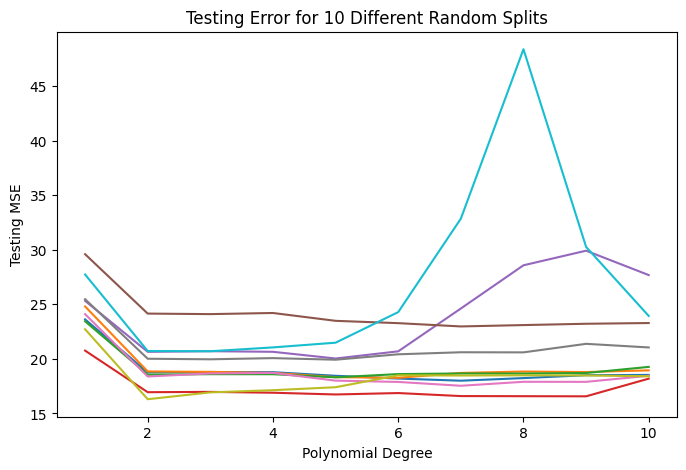

In [ ]:
# Repeat the validation-set approach with 10 different random splits

plt.figure(figsize=(8, 5))

for seed in range(10):

    # Make a different 50/50 training-validation split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.50,
        random_state=seed
    )

    test_mse = []

    # Evaluate every polynomial degree
    for degree in degrees:

        model = poly_model(degree)

        model.fit(X_train, y_train)

        y_test_pred = model.predict(X_test)

        test_mse.append(
            mean_squared_error(y_test, y_test_pred)
        )

    # One line for each random split
    plt.plot(degrees, test_mse)

plt.xlabel('Polynomial Degree'); plt.ylabel('Testing MSE'); plt.title('Testing Error for 10 Different Random Splits')
plt.show()

What is different here?

The first figure used one random split. The second repeats the exact same procedure 10 times, but changes which observations go into training and testing.

- Each line represents: one different train/testing split

- The testing error can change noticeably depending on which observations happen to land in the training and testing sets.

- One testing split may give us one answer about the best degree, while another split may give us a different answer.

This is the weakness of the simple validation-set approach (hold-out method). It motivates cross-validation.

### LOOCV vs. 10-fold cross-validation

Build the overall model

In [ ]:
#Compare LOOCV and 10-fold cross-validation
# Function that calculates cross-validation MSE
def cv_mse(degree, cv_method):

    model = poly_model(degree)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv_method,
        scoring='neg_mean_squared_error'
    )

    # scikit-learn returns negative MSE
    # Multiply by -1 to return regular positive MSE
    return -scores.mean()

Note: scoring='neg_mean_squared_error', **Why?**

scikit-learn's scoring tools (cross_val_score, GridSearchCV, and so on) all follow one rule: a higher score is always better. Error metrics like MSE go the other way, since lower is better. So scikit-learn negates them, and the name neg_mean_squared_error tells you the sign has been flipped.

This matters because GridSearchCV picks the setting with the highest score. If it used plain MSE, it would choose the worst model. With negative MSE, the largest value (closest to zero) is the best model.
The same "pick the max" logic works for accuracy, AUC and error metrics alike.

Use LOOCV in the model and time how long it takes to render all values

In [ ]:
# ----- LOOCV -----

start_time = time.time()

loo_mse = []

for degree in degrees:

    mse = cv_mse(
        degree,
        LeaveOneOut()
    )

    loo_mse.append(mse)

loo_time = time.time() - start_time

What LOOCV is doing?

Suppose the dataset contains \(n\) observations. For each degree:
- train on \(n-1\)
- validate on 1
- repeat \(n\) times
- average the errors

Use CV with k=10 and see how lonf it takes to render all values

In [ ]:
# ----- 10-fold cross-validation -----

start_time = time.time()

kfold10 = KFold(
    n_splits=10,
    shuffle=True,
    random_state=0
)

kfold_mse = []

for degree in degrees:

    mse = cv_mse(
        degree,
        kfold10
    )

    kfold_mse.append(mse)

kfold_time = time.time() - start_time

Here the data are divided into 10 folds. For each degree:
- train on 9 folds = about 90%
- validate on 1 fold = about 10%
- repeat 10 times
- average the 10 validation errors

In [ ]:
#Compare the running time
print(f'LOOCV time: {loo_time:.1f} seconds')
print(f'10-fold CV time: {kfold_time:.1f} seconds')

LOOCV time: 20.4 seconds
10-fold CV time: 0.5 seconds


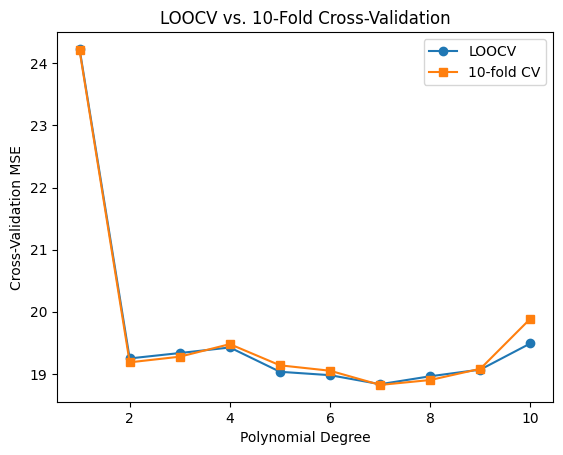

In [ ]:
#Graph
plt.plot(degrees, loo_mse, 'o-', label='LOOCV')

plt.plot(degrees, kfold_mse, 's-', label='10-fold CV')

plt.xlabel('Polynomial Degree')
plt.ylabel('Cross-Validation MSE')
plt.title('LOOCV vs. 10-Fold Cross-Validation')
plt.legend()
plt.show()

In [ ]:
best_degree = degrees[np.argmin(kfold_mse)]

print('Best degree using 10-fold CV:', best_degree)

Best degree using 10-fold CV: 7


### The Story

One split: “Let's split the data once and see which model complexity looks best.”

Repeat the split: “Wait! The answer changes depending on which observations we randomly put into training and validation.”

Cross-validation: “Instead of trusting one random split, let's systematically evaluate the models across multiple validation sets.”
Two options:
- LOOCV: almost all observations used for training each time, but many fits.
- 10-fold CV: 90% used for training each time, only 10 fits per model, and usually a very practical compromise.

**The 50/50 split happened to choose the same degree as 10-fold CV, but CV is more reliable because it does not depend on just one random split.**

### Part 2: Default (classification)

Prepare the classification data and hold out a final test set before tuning models.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Default.csv")

In [ ]:
df['default'] = (df['default'] == 'Yes').astype(int) #no=0, yes = 1
df['student'] = (df['student'] == 'Yes').astype(int)#no=0, yes = 1
print(df['default'].value_counts(normalize=True)) #Shows the proportion of each class.

default
0    0.9667
1    0.0333
Name: proportion, dtype: float64


We see that the Default dataset is imbalanced: most observations are non-defaults.

In [ ]:
#set features and target
X = df[['balance', 'income', 'student']]
y = df['default']

# Split the data into training and final test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25, #75% and 25%
    stratify=y,   #keeps the proportion of default/non-default cases similar
    random_state=0  #makes the split reproducible
    )

### **Model Selection with Cross-Validation**

Goal: Compare KNN, logistic regression, LDA, and QDA fairly using the same 5-fold cross-validation and the same scoring metric. We will tune the models that have clear hyperparameters, then compare their CV performance. The final test set stays untouched until we choose a winner.

In [ ]:
# -----------------------------
# KNN: tune k and weights
# -----------------------------

knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

knn_grid = {
    'kneighborsclassifier__n_neighbors': [1, 3, 5, 11, 21, 51],
    'kneighborsclassifier__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    knn,
    knn_grid,
    cv=5,
    scoring='roc_auc'
)

grid_knn.fit(X_train, y_train)


# -----------------------------
# Logistic Regression: tune C
# -----------------------------

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logreg_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    logreg,
    logreg_grid,
    cv=5,
    scoring='roc_auc'
)

grid_lr.fit(X_train, y_train)


# -----------------------------
# LDA: evaluate with CV
# -----------------------------

lda = LinearDiscriminantAnalysis()

lda_scores = cross_val_score(
    lda,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)


# -----------------------------
# QDA: evaluate with CV
# -----------------------------

qda = QuadraticDiscriminantAnalysis()

qda_scores = cross_val_score(
    qda,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)


# -----------------------------
# Compare results
# -----------------------------

print("KNN best parameters:", grid_knn.best_params_)
print("KNN best CV ROC-AUC:", round(grid_knn.best_score_, 4))

print("\nLogistic Regression best parameters:", grid_lr.best_params_)
print("Logistic Regression best CV ROC-AUC:", round(grid_lr.best_score_, 4))

print("\nLDA mean CV ROC-AUC:", round(lda_scores.mean(), 4))

print("QDA mean CV ROC-AUC:", round(qda_scores.mean(), 4))

KNN best parameters: {'kneighborsclassifier__n_neighbors': 51, 'kneighborsclassifier__weights': 'uniform'}
KNN best CV ROC-AUC: 0.9221

Logistic Regression best parameters: {'logisticregression__C': 0.1}
Logistic Regression best CV ROC-AUC: 0.946

LDA mean CV ROC-AUC: 0.946
QDA mean CV ROC-AUC: 0.9443


- KNN is the weakest of the four here, with a CV ROC-AUC of 0.9221. Also, its best (k) is 51, which is the largest value in your grid. That suggests you should probably extend the KNN search to larger (k)values before declaring its final best setting.


- Logistic regression and LDA are essentially tied at 0.9460. QDA is very close at 0.9443.

If the score difference between all of them is very small, prefer the simpler/easier-to-explain model. Logistic regression or LDA.

I would not call one clearly better from these mean scores alone. You should compare the fold-to-fold spread next.

In [ ]:
# Get the 5 fold scores for the best logistic regression model
lr_scores = cross_val_score(
    grid_lr.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

#logistic fold-by-fold
print(lr_scores)

# LDA fold-by-fold scores
print(lda_scores)

[0.9318069  0.95176552 0.95758621 0.93710345 0.9518069 ]
[0.93158621 0.95197241 0.95771034 0.93678621 0.95217931]


Because the fold-by-fold results are nearly identical, we can treat logistic regression and LDA as essentially tied and prefer the simpler to us or the one we could easier-to-explain.

### **Hyperparameter Tuning with Different Scoring Metrics**

Use the Iris dataset to show that hyperparameter tuning depends on the scoring metric we choose. We will tune logistic regression’s C using 5-fold cross-validation and compare the best C selected by accuracy, F1 macro, and ROC-AUC. The final test set is kept separate and is not used during tuning.

In [ ]:
# Load Iris data
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

# Split into training and final test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

In [ ]:
# Logistic regression pipeline
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)   #allow lr up to 1000 iterations to find the coefficient values that optimize the model.
)

# Values of C to try
grid = {
    'logisticregression__C': np.logspace(-3, 3, 7) #creates 7 values spaced evenly on a logarithmic scale from 10^-3 to10^3
}                                                  #[0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Compare different scoring metrics
for scoring in ['accuracy', 'f1_macro', 'roc_auc_ovr']:

    gs = GridSearchCV(
        pipe,
        grid,
        cv=5,
        scoring=scoring
    ).fit(X_train, y_train)

    print(
        f'{scoring:12s} '
        f'best C={gs.best_params_["logisticregression__C"]:<8} '
        f'CV score={gs.best_score_:.3f}'
    )

accuracy     best C=100.0    CV score=0.964
f1_macro     best C=100.0    CV score=0.964
roc_auc_ovr  best C=1.0      CV score=0.997


- Accuracy = 0.964 with C = 100
  Accuracy is the proportion of all predictions that are correct. Here, the model correctly classifies about 96.4% of observations.
- F1 macro = 0.964 with C = 100
  F1 macro calculates the F1 score for each Iris class separately and then averages them equally. A value of 0.964 means precision and recall are both strong across the three classes.
- ROC-AUC OVR = 0.997 with C = 1
  roc_auc_ovr measures how well the model separates each class from the others across many possible thresholds. A value of 0.997 is extremely high.


The important result is that accuracy and F1 macro choose C = 100, while ROC-AUC chooses C = 1.
For Iris, I would probably choose the model based on accuracy or F1 macro, because F1 macro gives the most honest view of multiclass performance. AUC measures how well the model ranks positive vs negative instances—not whether it makes correct class assignments.

Notes:
- F1 score is usually used for binary classification. It combines precision and recall for the positive class into one number. **Use** when you care about overall predictions and want frequent classes to drive the evaluation metric.
- F1 macro is used for multiclass classification. It calculates the F1 score separately for each class, then takes the simple average of those F1 scores. **Use** Use when all classes are equally critical to your business or problem, in a balanced data, or in an imbalanced datasets where rare classes still matter